# TODO

- Add more markdown comments to document every choice made in the pipeline


# Dataset


## Setup


### Imports


In [1]:
import os
import subprocess
import xml.etree.ElementTree as ET

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

### Environment


In [2]:
os.environ["SUMO_HOME"] = os.path.join(os.environ["CONDA_PREFIX"], "Lib", "site-packages", "sumo")
SUMO_HOME = os.environ["SUMO_HOME"]
os.environ["PATH"] += os.pathsep + os.path.join(SUMO_HOME, "bin")
os.environ["PATH"] += os.pathsep + os.path.join(SUMO_HOME, "tools")

### Constants


For the traffic generation periods, we tried to have as realistic as possible traffic patterns. This includes a morning rush hour, a lunch break, and an evening rush hour. A useful reference for traffic patterns in Athens is the [Athens Mobility Observatory](https://amob.ntua.gr/traffic/).


In [3]:
np.random.seed(42)

DATASET_DIR = os.path.join("athens-osmWebWizard")

OSM_WEB_WIZARD_PATH = os.path.join(SUMO_HOME, "tools", "osmWebWizard.py")
RANDOM_TRIPS_PATH = os.path.join(SUMO_HOME, "tools", "randomTrips.py")
NETWORK_PATH = os.path.join(DATASET_DIR, "osm.net.xml.gz")
DUAROUTER_PATH = os.path.join(SUMO_HOME, "bin", "duarouter.exe")
FCD_TRAIN_DATASET_PATH = os.path.join(DATASET_DIR, "fcd-train-athens-10h.xml")
FCD_TEST_DATASET_PATH = os.path.join(DATASET_DIR, "fcd-test-athens-10h.xml")
XML_2_CSV_PATH = os.path.join(SUMO_HOME, "tools", "xml", "xml2csv.py")

TRAIN_TRAFFIC_GENERATION_PERIODS = [0.45, 0.50, 0.65, 0.75, 0.80, 0.80, 0.75, 0.55, 0.50, 0.55]
TEST_TRAFFIC_GENERATION_PERIODS = [p * np.random.uniform(0.98, 1.02) for p in TRAIN_TRAFFIC_GENERATION_PERIODS]

## OSM Web Wizard


To generate the network, we can use the [OSM Web Wizard](https://sumo.dlr.de/docs/Tutorials/OSMWebWizard.html). For options, we selected the following:

- Position: Athens (for more details, see `dataset/athens-osmWebWizard/images/athens-map.png`)
- Duration: 36000 seconds (10 hours)
- Add Polygons: Enabled
- Car-only Network: Enabled
- Random Traffic Generation: Disabled All


In [4]:
!python $SUMO_HOME/tools/osmWebWizard.py

^C


## Preparation


### Random Trips


To generate random trips, we can use the [randomTrips.py](https://sumo.dlr.de/docs/Tools/Trip.html) script from the SUMO tools.

This script generates random trips based on the network and the specified parameters. The generated trips are saved in a file that can be used for simulation.


In [4]:
def generate_random_trips(prefix, traffic_generation_periods, seed, simulation_start=0, simulation_end=36000):
    traffic_generation_periods_str = ",".join(str(v) for v in traffic_generation_periods)
    trips_file = os.path.join(DATASET_DIR, f"{prefix}.trips.xml")
    routes_temp_file = "routes.rou.xml"

    command = [
        "python",
        RANDOM_TRIPS_PATH,
        "--net-file",
        NETWORK_PATH,
        "--begin",
        str(simulation_start),
        "--end",
        str(simulation_end),
        "--period",
        traffic_generation_periods_str,
        "-o",
        trips_file,
        "--seed",
        str(seed),
        "--validate",
    ]

    print("Executing:", " ".join(command))
    result = subprocess.run(command, capture_output=True, text=True)
    if result.stderr:
        print("Errors/Warnings from randomTrips:")
        print(result.stderr)

    if os.path.exists(trips_file) and os.path.exists(routes_temp_file):
        os.remove(routes_temp_file)
        print("Success:", trips_file)
    else:
        print("Failed:", trips_file)


print("Generating train random trips...")
generate_random_trips("train", TRAIN_TRAFFIC_GENERATION_PERIODS, 1)
print("Generating test random trips...")
generate_random_trips("test", TEST_TRAFFIC_GENERATION_PERIODS, 42)

Generating train random trips...
Executing: python C:\Users\george\miniconda3\envs\thesis\Lib\site-packages\sumo\tools\randomTrips.py --net-file athens-osmWebWizard\osm.net.xml.gz --begin 0 --end 36000 --period 0.45,0.5,0.65,0.75,0.8,0.8,0.75,0.55,0.5,0.55 -o athens-osmWebWizard\train.trips.xml --seed 1 --validate
Success: athens-osmWebWizard\train.trips.xml
Generating test random trips...
Executing: python C:\Users\george\miniconda3\envs\thesis\Lib\site-packages\sumo\tools\randomTrips.py --net-file athens-osmWebWizard\osm.net.xml.gz --begin 0 --end 36000 --period 0.44774172213925256,0.5090142861281983,0.6560318424870966,0.752959754525911,0.788992596494158,0.7889918246507586,0.736742508365046,0.5580558752070487,0.5020223002348642,0.5545775967115131 -o athens-osmWebWizard\test.trips.xml --seed 42 --validate
Success: athens-osmWebWizard\test.trips.xml


### Trip IDs


In [5]:
def update_trip_ids(prefix):
    trips_file = os.path.join(DATASET_DIR, f"{prefix}.trips.xml")
    if not os.path.exists(trips_file):
        print(f"Trips file not found: {trips_file}")
        return

    tree = ET.parse(trips_file)
    root = tree.getroot()

    trip_id = 0
    for trip in root.findall("trip"):
        trip.set("id", str(trip_id))
        trip_id += 1

    tree.write(trips_file)
    print("Updated:", trips_file)


print("Updating train trip IDs...")
update_trip_ids("train")
print("Updating test trip IDs...")
update_trip_ids("test")

Updating train trip IDs...
Updated: athens-osmWebWizard\train.trips.xml
Updating test trip IDs...
Updated: athens-osmWebWizard\test.trips.xml


### Vehicle Types


For the vehicle types, we ended up going with just cars. We have also defined a few more vehicle types, but they are not used in the dataset. These can be found on the `dataset/athens-osmWebWizard/vtypes.xml` file. The vehicle types are as follows:

- Standard Passenger Car
- Light Duty Vehicle
- Heavy Duty Vehicle
- Bus

The above vehicle types and their parameters are based on the following resources:

- [SUMO Vehicle Types](https://sumo.dlr.de/docs/Definition_of_Vehicles,_Vehicle_Types,_and_Routes.html#vehicle_types)
- [SUMO Vehicle Type Parameter Defaults](https://sumo.dlr.de/docs/Vehicle_Type_Parameter_Defaults.html)
- [SUMO HBEFA3-based Emissions](https://sumo.dlr.de/docs/Models/Emissions/HBEFA3-based.html)


In [6]:
def update_vehicle_types(prefix):
    trips_file = os.path.join(DATASET_DIR, f"{prefix}.trips.xml")
    if not os.path.exists(trips_file):
        print(f"Trips file not found: {trips_file}")
        return

    tree = ET.parse(trips_file)
    root = tree.getroot()

    for trip in root.findall("trip"):
        trip.set("type", "car")

    tree.write(trips_file)
    print("Updated:", trips_file)


print("Updating train vehicle types...")
update_vehicle_types("train")
print("Updating test vehicle types...")
update_vehicle_types("test")

Updating train vehicle types...
Updated: athens-osmWebWizard\train.trips.xml
Updating test vehicle types...
Updated: athens-osmWebWizard\test.trips.xml


### Fixed Routes


Following, we have defined a few fixed routes. These routes are used on the test dataset, so that we have specific ground truths for visualization and evaluation purposes. These routes are fixed and are not rerouted during the simulation.

The flows were constructed using the [netedit](https://sumo.dlr.de/docs/Netedit/index.html) tool of SUMO. For now we only have one trip, with two different routes. The trip is **Omonoia to Evangelismos** and the routes are **via Akadimias** (Route A) and **via Stadiou** (Route B). The routes are as follows:

- **Route A - Via Akadimias**: 23182962 (Stadiou) > 260124786#0 (Akadimias) > 1209362820 (Pl. Filikis Eterias) > 299645496 (Marasli) > 169130585 (Leof. Vasilissis Sofias)
- **Route B - Via Stadiou**: 23182962 (Stadiou) > 299506410#0 (Stadiou) > 221139568 (Leof. Vasilissis Amalias) > -820421378#1 (Leof. Vasilissis Sofias) > 169130585 (Leof. Vasilissis Sofias)


In [8]:
!netedit athens-osmWebWizard/osm.net.xml.gz

In [7]:
def generate_fixed_routes():
    fixed_flows_file = os.path.join(DATASET_DIR, "fixed.flows.xml")
    fixed_routes_file = os.path.join(DATASET_DIR, "fixed.rou.xml")
    fixed_routes_alt_file = os.path.join(DATASET_DIR, "fixed.rou.alt.xml")

    command = [
        DUAROUTER_PATH,
        "--net-file",
        NETWORK_PATH,
        "--route-files",
        fixed_flows_file,
        "--output-file",
        fixed_routes_file,
    ]

    print("Executing:", " ".join(command))
    result = subprocess.run(command, capture_output=True, text=True)

    if result.stderr:
        print("Errors/Warnings from duarouter:")
        print(result.stderr)

    if os.path.exists(fixed_routes_file) and os.path.exists(fixed_routes_alt_file):
        os.remove(fixed_routes_alt_file)
        print("Success:", fixed_routes_file)
    else:
        print("Failed:", fixed_routes_file)


print("Generating fixed routes...")
generate_fixed_routes()

Generating fixed routes...
Executing: C:\Users\george\miniconda3\envs\thesis\Lib\site-packages\sumo\bin\duarouter.exe --net-file athens-osmWebWizard\osm.net.xml.gz --route-files athens-osmWebWizard\fixed.flows.xml --output-file athens-osmWebWizard\fixed.rou.xml
Success: athens-osmWebWizard\fixed.rou.xml


## Simulation


For the simulation, we can use either the command line [sumo](https://sumo.dlr.de/docs/sumo.html) or launch the [sumo-gui](https://sumo.dlr.de/docs/sumo-gui.html).


In [8]:
!sumo -c athens-osmWebWizard/train.sumocfg

Loading net-file from 'athens-osmWebWizard/osm.net.xml.gz' ... done (234ms).
Loading additional-files from 'athens-osmWebWizard/osm.poly.xml.gz' ... done (408ms).
Loading additional-files from 'athens-osmWebWizard/vtypes.xml' ... done (3ms).
Loading done.
Simulation version 1.21.0 started with time: 0.00.
Simulation ended at time: 36481.00.
Reason: All vehicles have left the simulation.
Performance:
 Duration: 376.50s
 Real time factor: 96.8956
 UPS: 33106.167895
Vehicles:
 Inserted: 57474
 Running: 0
 Waiting: 0
 Teleports: 136 (Jam: 36, Yield: 92, Wrong Lane: 8)
Statistics (avg of 57474):
 RouteLength: 1729.59
 Speed: 8.32
 Duration: 216.87
 WaitingTime: 44.17
 TimeLoss: 113.00
 DepartDelay: 1.10
DijkstraRouter answered 57528 queries and explored 562.08 edges on average.
DijkstraRouter spent 22.40s answering queries (0.39ms on average).


In [9]:
!sumo -c athens-osmWebWizard/test.sumocfg

Loading net-file from 'athens-osmWebWizard/osm.net.xml.gz' ... done (104ms).
Loading additional-files from 'athens-osmWebWizard/osm.poly.xml.gz' ... done (230ms).
Loading additional-files from 'athens-osmWebWizard/vtypes.xml' ... done (2ms).
Loading done.
Simulation version 1.21.0 started with time: 0.00.
Simulation ended at time: 36331.00.
Reason: All vehicles have left the simulation.
Performance:
 Duration: 378.56s
 Real time factor: 95.9721
 UPS: 32474.159838
Vehicles:
 Inserted: 57525
 Running: 0
 Waiting: 0
 Teleports: 82 (Collisions: 2, Jam: 22, Yield: 52, Wrong Lane: 6)
 Emergency Braking: 2
Statistics (avg of 57525):
 RouteLength: 1736.55
 Speed: 8.38
 Duration: 213.70
 WaitingTime: 40.97
 TimeLoss: 109.65
 DepartDelay: 1.07
DijkstraRouter answered 57452 queries and explored 563.82 edges on average.
DijkstraRouter spent 22.48s answering queries (0.39ms on average).


## Exploratory Data Analysis


### XML Parsing


In [10]:
def parse_fcd_output_xml(file_path):
    records = []
    context = ET.iterparse(file_path, events=("end",))
    for _, elem in context:
        if elem.tag == "timestep":
            time = float(elem.get("time"))
            for veh in elem.findall("vehicle"):
                speed_ms = float(veh.get("speed"))
                records.append(
                    {
                        "timestep_time": time,
                        "vehicle_id": veh.get("id"),
                        "x": float(veh.get("x")),
                        "y": float(veh.get("y")),
                        "vehicle_type": veh.get("type"),
                        "speed_kmh": speed_ms * 3.6,
                        "acceleration": float(veh.get("acceleration")),
                        "odometer": float(veh.get("odometer")),
                    }
                )
            elem.clear()
    return pd.DataFrame(records)


print("Parsing train FCD output...")
train_df = parse_fcd_output_xml(FCD_TRAIN_DATASET_PATH)
print("Parsing test FCD output...")
test_df = parse_fcd_output_xml(FCD_TEST_DATASET_PATH)

Parsing train FCD output...
Parsing test FCD output...


### Overview


In [11]:
train_df = train_df.dropna().reset_index(drop=True)
test_df = test_df.dropna().reset_index(drop=True)

train_df = train_df[train_df["timestep_time"] < 36000].reset_index(drop=True)
test_df = test_df[test_df["timestep_time"] < 36000].reset_index(drop=True)

for df, df_name in [(train_df, "train"), (test_df, "test")]:
    print(f"Dataset: {df_name}")
    print(f"Data shape: {df.shape}")
    print(f"Average speed: {df['speed_kmh'].mean():.2f} km/h")
    print(f"Average distance (max odometer): {df.groupby('vehicle_id')['odometer'].max().mean():.2f} m")
    print(f"Unique vehicles: {df['vehicle_id'].nunique()}")
    print(f"Time span: {df['timestep_time'].min():.2f} s to {df['timestep_time'].max():.2f} s")
    if df_name == "train":
        print()

Dataset: train
Data shape: (12417495, 8)
Average speed: 28.61 km/h
Average distance (max odometer): 1716.80 m
Unique vehicles: 57472
Time span: 0.00 s to 35999.00 s

Dataset: test
Data shape: (12246385, 8)
Average speed: 29.14 km/h
Average distance (max odometer): 1723.05 m
Unique vehicles: 57523
Time span: 0.00 s to 35999.00 s


### Data Engineering


In [12]:
train_df["second"] = train_df["timestep_time"].astype(int)
train_df["hour"] = (train_df["timestep_time"] // 3600).astype(int)
train_secondly = (
    train_df.groupby("second")
    .agg(avg_speed_kmh=("speed_kmh", "mean"), vehicle_count=("vehicle_id", "nunique"))
    .reset_index()
)
train_hourly = (
    train_df.groupby("hour")
    .agg(avg_speed_kmh=("speed_kmh", "mean"), vehicle_count=("vehicle_id", "nunique"))
    .reset_index()
)

test_df["second"] = test_df["timestep_time"].astype(int)
test_df["hour"] = (test_df["timestep_time"] // 3600).astype(int)
test_secondly = (
    test_df.groupby("second")
    .agg(avg_speed_kmh=("speed_kmh", "mean"), vehicle_count=("vehicle_id", "nunique"))
    .reset_index()
)
test_hourly = (
    test_df.groupby("hour")
    .agg(avg_speed_kmh=("speed_kmh", "mean"), vehicle_count=("vehicle_id", "nunique"))
    .reset_index()
)

### Speed Distribution


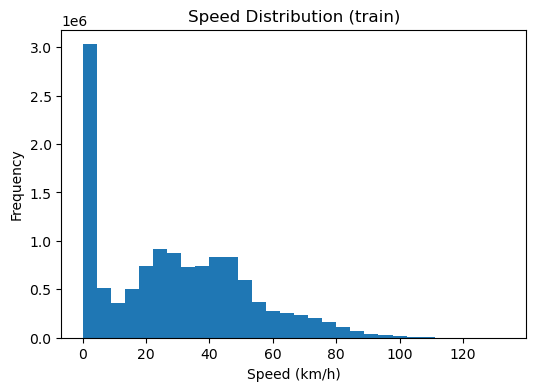

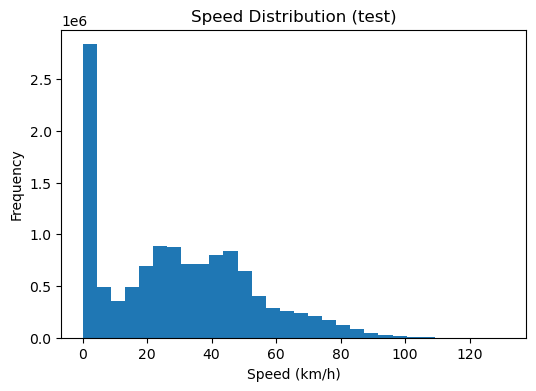

In [13]:
for df, df_name in [(train_df, "train"), (test_df, "test")]:
    plt.figure(figsize=(6, 4))
    plt.hist(df["speed_kmh"], bins=30)
    plt.title(f"Speed Distribution ({df_name})")
    plt.xlabel("Speed (km/h)")
    plt.ylabel("Frequency")
    plt.show()

### Average Speed per Second


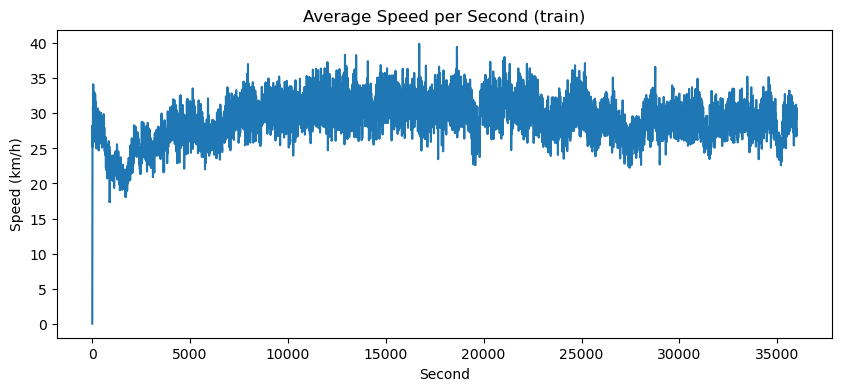

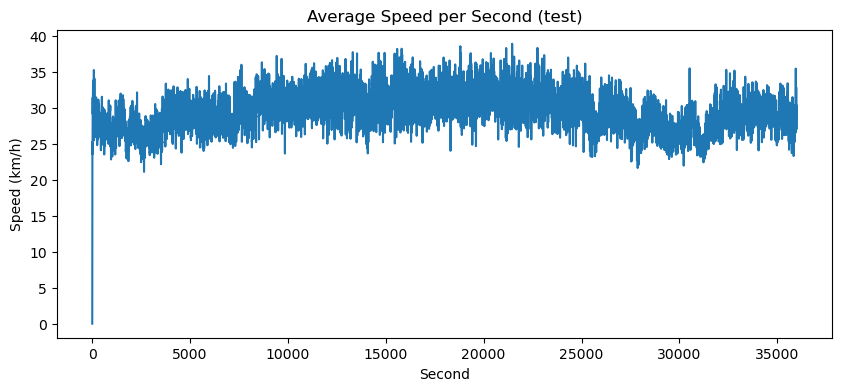

In [14]:
for df, df_name in [(train_secondly, "train"), (test_secondly, "test")]:
    plt.figure(figsize=(10, 4))
    plt.plot(df["second"], df["avg_speed_kmh"])
    plt.title(f"Average Speed per Second ({df_name})")
    plt.xlabel("Second")
    plt.ylabel("Speed (km/h)")
    plt.show()

### Vehicle Count per Second


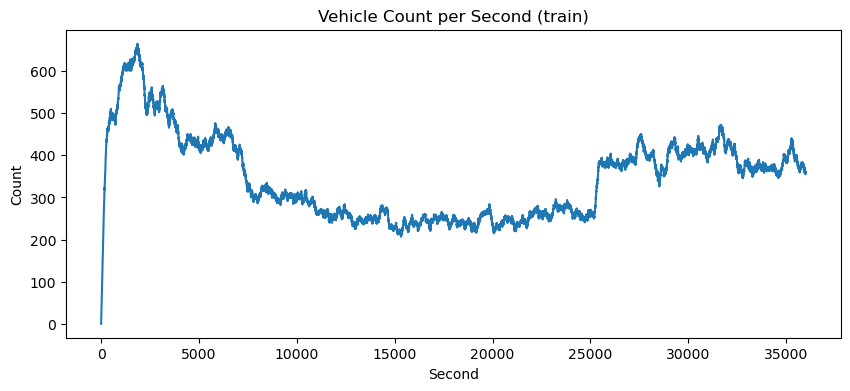

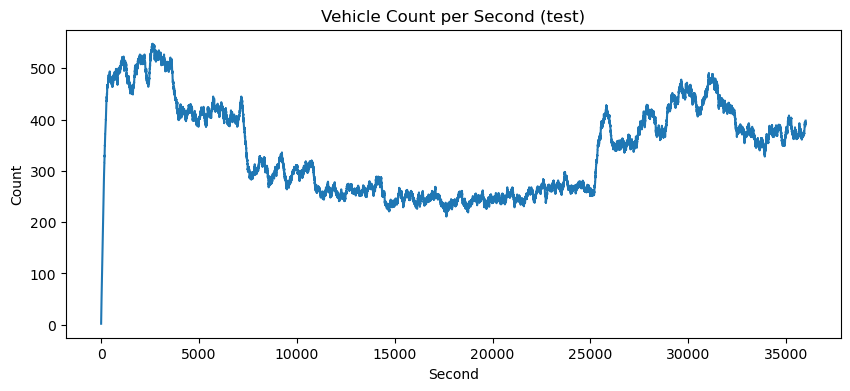

In [15]:
for df, df_name in [(train_secondly, "train"), (test_secondly, "test")]:
    plt.figure(figsize=(10, 4))
    plt.plot(df["second"], df["vehicle_count"])
    plt.title(f"Vehicle Count per Second ({df_name})")
    plt.xlabel("Second")
    plt.ylabel("Count")
    plt.show()

### Average Speed per Hour


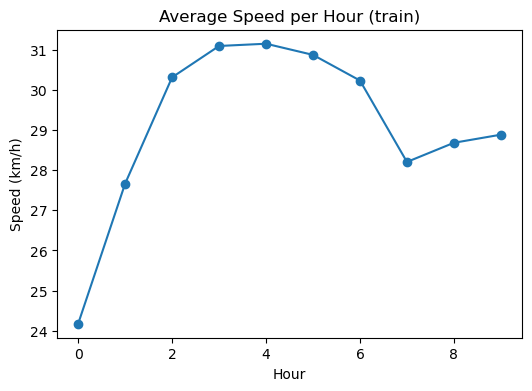

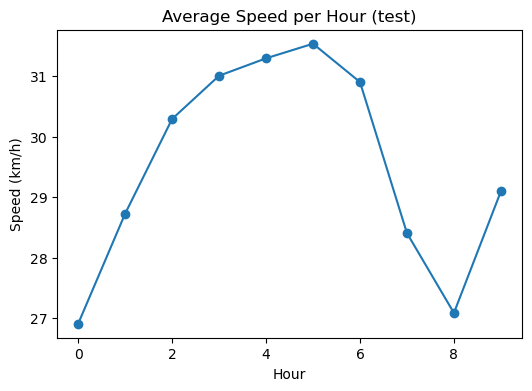

In [16]:
for df, df_name in [(train_hourly, "train"), (test_hourly, "test")]:
    plt.figure(figsize=(6, 4))
    plt.plot(df["hour"], df["avg_speed_kmh"], marker="o")
    plt.title(f"Average Speed per Hour ({df_name})")
    plt.xlabel("Hour")
    plt.ylabel("Speed (km/h)")
    plt.show()

### Vehicle Count per Hour


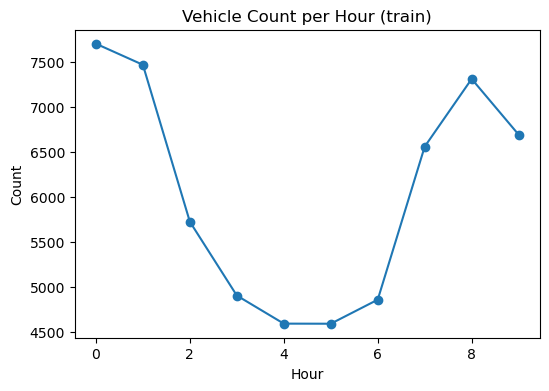

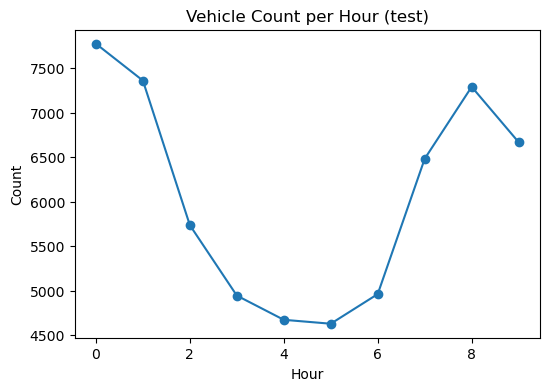

In [17]:
for df, df_name in [(train_hourly, "train"), (test_hourly, "test")]:
    plt.figure(figsize=(6, 4))
    plt.plot(df["hour"], df["vehicle_count"], marker="o")
    plt.title(f"Vehicle Count per Hour ({df_name})")
    plt.xlabel("Hour")
    plt.ylabel("Count")
    plt.show()

### Vehicle Count and Speed over Time


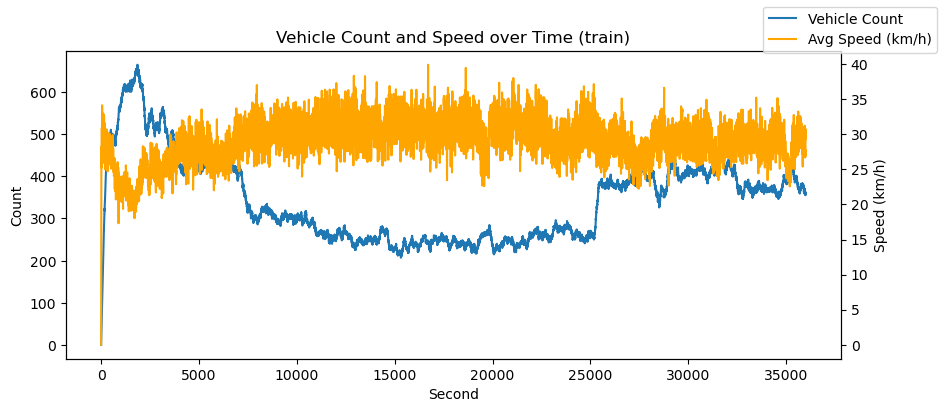

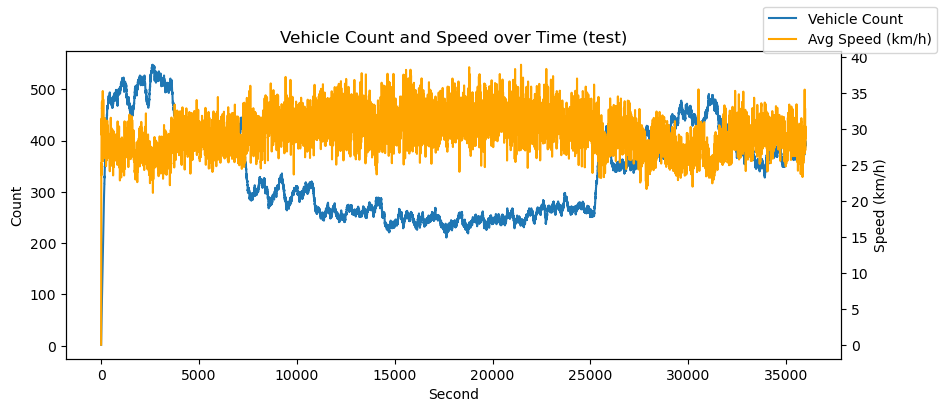

In [18]:
for df, df_name in [(train_secondly, "train"), (test_secondly, "test")]:
    fig, ax1 = plt.subplots(figsize=(10, 4))
    ax1.plot(df["second"], df["vehicle_count"], label="Vehicle Count")
    ax1.set_xlabel("Second")
    ax1.set_ylabel("Count")
    ax2 = ax1.twinx()
    ax2.plot(df["second"], df["avg_speed_kmh"], label="Avg Speed (km/h)", color="orange")
    ax2.set_ylabel("Speed (km/h)")
    fig.legend(loc="upper right")
    plt.title(f"Vehicle Count and Speed over Time ({df_name})")
    plt.show()

### Average Speed and Traffic Generation Periods per Hour


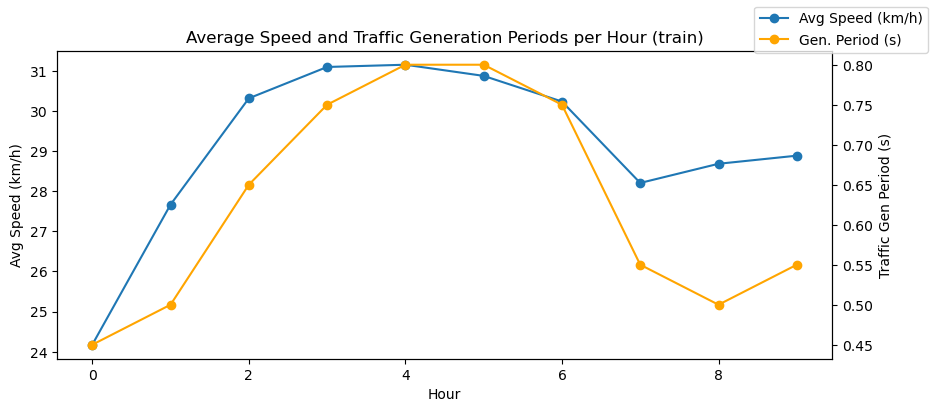

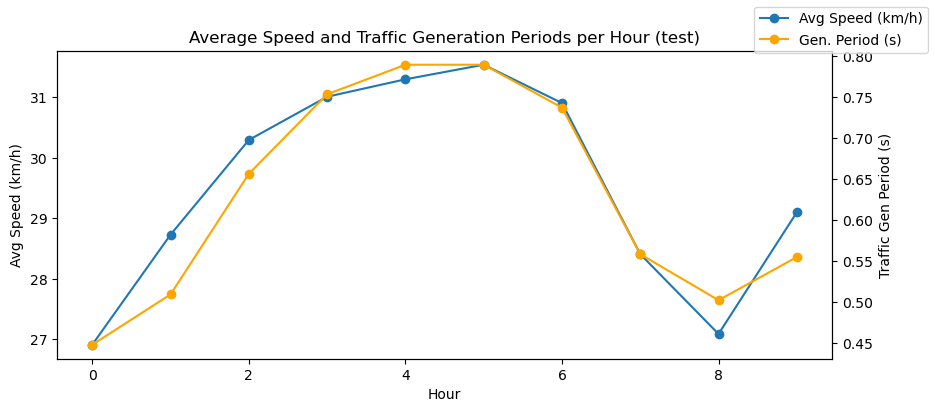

In [19]:
for df, df_name, periods in [
    (train_hourly, "train", TRAIN_TRAFFIC_GENERATION_PERIODS),
    (test_hourly, "test", TEST_TRAFFIC_GENERATION_PERIODS),
]:
    fig, ax1 = plt.subplots(figsize=(10, 4))
    ax1.plot(df["hour"], df["avg_speed_kmh"], marker="o", label="Avg Speed (km/h)")
    ax1.set_xlabel("Hour")
    ax1.set_ylabel("Avg Speed (km/h)")
    ax2 = ax1.twinx()
    ax2.plot(df["hour"], periods, marker="o", label="Gen. Period (s)", color="orange")
    ax2.set_ylabel("Traffic Gen Period (s)")
    fig.legend(loc="upper right")
    plt.title(f"Average Speed and Traffic Generation Periods per Hour ({df_name})")
    plt.show()

## Conversion to CSV


To convert the xml output files to csv, we can use the [xml2csv.py](https://sumo.dlr.de/docs/Tools/Xml.html#xml2csvpy) tool of SUMO.


In [ ]:
!python $SUMO_HOME/tools/xml/xml2csv.py athens-osmWebWizard/dump-train-athens-10h.xml
!python $SUMO_HOME/tools/xml/xml2csv.py athens-osmWebWizard/emission-train-athens-10h.xml
!python $SUMO_HOME/tools/xml/xml2csv.py athens-osmWebWizard/fcd-train-athens-10h.xml

In [ ]:
!python $SUMO_HOME/tools/xml/xml2csv.py athens-osmWebWizard/dump-test-athens-10h.xml
!python $SUMO_HOME/tools/xml/xml2csv.py athens-osmWebWizard/emission-test-athens-10h.xml
!python $SUMO_HOME/tools/xml/xml2csv.py athens-osmWebWizard/fcd-test-athens-10h.xml

In [ ]:
!rm athens-osmWebWizard/dump-train-athens-10h.xml
!rm athens-osmWebWizard/emission-train-athens-10h.xml
!rm athens-osmWebWizard/fcd-train-athens-10h.xml
!rm athens-osmWebWizard/dump-test-athens-10h.xml
!rm athens-osmWebWizard/emission-test-athens-10h.xml
!rm athens-osmWebWizard/fcd-test-athens-10h.xml

## Concept Drift


- Disable single edge (road closure)
- Disable multiple edges (cycling event)
- Disable single lane (accident)
- Disable multiple lanes (road works)
- Increase of traffic on certain area (concert or football match)
- Increase of traffic on whole area (holidays)
- Reduction of traffic on certain area (shut down of a factory)
- Reduction of traffic on whole area (holidays)
- Global reduction of speed (weather)
- Global increase of vehicle following gaps (weather)
- Global decrease of acceleration (weather)
- Global increase of deceleration (weather)
